In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import matplotlib.pyplot as plt
import seaborn as sns

### Get logistic regression results

conducted logistic regression with age and top 10 PCs in non-discovery cohort

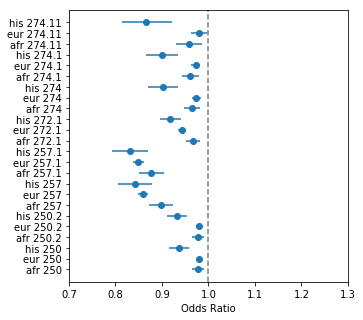

In [3]:
logreg_results=pd.read_excel("../data/prs-logreg/compiled.prs.logreg.results.xlsx")

logreg_results["phecode"]=logreg_results["file"].str.split(".logreg").str[0]
logreg_results["phecode"]=logreg_results["phecode"].str.split(".",n=1).str[1]

#phecode list
phecode_lst=["257","257.1","274.1","272.1","274","274.11","272.1","250","250.2","282"]

logreg_results=logreg_results[logreg_results["phecode"].isin(phecode_lst)]
logreg_results["err1"]=logreg_results["Odds Ratio"]-logreg_results[0.05]
logreg_results["err2"]=logreg_results[0.95]-logreg_results["Odds Ratio"]

logreg_results["cat"]=logreg_results["group"]+" "+logreg_results["phecode"]

logreg_results=logreg_results.sort_values(by=["phecode","group"])

logreg_results["color"]=logreg_results["group"].map({"eur":"r","afr":"b","his":"g"})

f=plt.figure(figsize=(5,5))
plt.errorbar(logreg_results["Odds Ratio"],logreg_results["cat"],xerr=[logreg_results["err1"],logreg_results["err2"]],fmt="o")
plt.xlim(0.7,1.3)
plt.axvline(1,linestyle="--",color="gray")
plt.xlabel("Odds Ratio")
plt.savefig("../plots/prs/prs.logreg.pdf")